# Volcanic Eruptions

**Category:** Data Cleaning  
**Dataset:** volcanic-eruptions.csv (3,724 rows) + volcano-list.csv (1,281 rows)  
**Objective:** Parse dates correctly, merge two linked datasets, and find
currently-erupting volcanoes and the longest recorded eruptions in history.

---

In [2]:
# Goal: Identify currently-erupting volcanoes and the longest eruptions in 
# history, by correctly parsing dates and merging two linked datasets.

import pandas as pd
import matplotlib.pyplot as plt

eruptions = pd.read_csv('../data/volcanic-eruptions.csv')
volcanoes = pd.read_csv('../data/volcano-list.csv')

eruptions.head(3)

,volcano_id,start_date,end_date
0,211020,07-1913,04-1944
1,211020,02-1864,11-1868
2,211020,12-1854,05-1855


In [3]:
volcanoes.head(3)

,volcano_id,volcano_name,country,volcanic_region_group,volcanic_region,volcano_landform,primary_volcano_type,activity_evidence,last_known_eruption,latitude,longitude,elevation_m,tectonic_setting,dominant_rock_type
0,210010,West Eifel Volcanic Field,Germany,European Volcanic Regions,Central European Volcanic Province,Cluster,Volcanic field,Eruption Dated,8300 BCE,50.170,6.850,600,Rift zone / Continental crust (>25 km),Foidite
1,210020,Chaine des Puys,France,European Volcanic Regions,Western European Volcanic Province,Cluster,Lava dome(s),Eruption Dated,4040 BCE,45.786,2.981,1464,Rift zone / Continental crust (>25 km),Basalt / Picro-Basalt
2,210030,Olot Volcanic Field,Spain,European Volcanic Regions,Western European Volcanic Province,Cluster,Volcanic field,Evidence Credible,Unknown,42.170,2.530,893,Intraplate / Continental crust (>25 km),Trachybasalt / Tephrite Basanite


## 1. Dataset Exploration

Exploring both files independently before attempting anything with them
together. Checking whether the volcano_id counts roughly correspond
between the two files is a useful early sanity check.

In [4]:
print("=== Eruptions ===")
print("Shape: ", eruptions.shape)
print("Dtypes: ")
print(eruptions.dtypes)
print()

print("=== Volcanoes ===")
print("Shape: ", volcanoes.shape)
print("Missing Values: ")
print(volcanoes.isnull().sum())
print()

print("Unique volcano_ids in eruptions: ", eruptions['volcano_id'].nunique())
print("Total number of rows in volcano-list: ", len(volcanoes))

=== Eruptions ===
Shape:  (3724, 3)
Dtypes: 
volcano_id    int64
start_date      str
end_date        str
dtype: object

=== Volcanoes ===
Shape:  (1281, 14)
Missing Values: 
volcano_id                0
volcano_name              0
country                   0
volcanic_region_group     0
volcanic_region           0
volcano_landform          0
primary_volcano_type      0
activity_evidence         0
last_known_eruption       0
latitude                  0
longitude                 0
elevation_m               0
tectonic_setting          5
dominant_rock_type       25
dtype: int64

Unique volcano_ids in eruptions:  426
Total number of rows in volcano-list:  1281


## 2. Cleaning: Parse Dates

The format is consistently MM-YYYY 
(e.g. "07-1913"). Passing an explicit format string to pd.to_datetime()
is faster and safer than letting pandas guess, guessing can silently
misparse ambiguous formats or run much slower.

In [10]:
eruptions['start_parsed'] = pd.to_datetime(
    eruptions['start_date'], 
    format='%M-%Y'
)
eruptions['end_parsed'] = pd.to_datetime(
    eruptions['end_date'], 
    format='%M-%Y'
)

eruptions[['start_date', 'start_parsed', 'end_date', 'end_parsed']].head()

,start_date,start_parsed,end_date,end_parsed
0,07-1913,1913-01-01 00:07:00,04-1944,1944-01-01 00:04:00
1,02-1864,1864-01-01 00:02:00,11-1868,1868-01-01 00:11:00
2,12-1854,1854-01-01 00:12:00,05-1855,1855-01-01 00:05:00
3,12-1855,1855-01-01 00:12:00,12-1861,1861-01-01 00:12:00
4,07-1824,1824-01-01 00:07:00,09-1834,1834-01-01 00:09:00


## 3. Feature Engineering: Eruption Duration

Computing how many days each eruption lasted, using the two parsed
date columns.

In [11]:
eruptions['duration_days'] = (
    eruptions['end_parsed'] - eruptions['start_parsed']
).dt.days

eruptions[['volcano_id', 'start_date', 'end_date', 'duration_days']].head()

,volcano_id,start_date,end_date,duration_days
0,211020,07-1913,04-1944,11321
1,211020,02-1864,11-1868,1461
2,211020,12-1854,05-1855,364
3,211020,12-1855,12-1861,2192
4,211020,07-1824,09-1834,3653


## 4. Cleaning: Reduce Columns Before Merging

volcano-list.csv has 14 columns; only a few are needed here. Reducing the column
first keeps the merged result readable.

In [16]:
volcano_info = volcanoes[['volcano_id', 'volcano_name', 'country', 'primary_volcano_type']]
eruption_subset = eruptions[['volcano_id', 'start_date', 'end_date', 'duration_days']]

volcano_info.head()

,volcano_id,volcano_name,country,primary_volcano_type
0,210010,West Eifel Volcanic Field,Germany,Volcanic field
1,210020,Chaine des Puys,France,Lava dome(s)
2,210030,Olot Volcanic Field,Spain,Volcanic field
3,210040,Calatrava Volcanic Field,Spain,Volcanic field
4,211004,Colli Albani,Italy,Caldera


In [13]:
eruption_subset.head()

,volcano_id,start_date,end_date,duration_days
0,211020,07-1913,04-1944,11321
1,211020,02-1864,11-1868,1461
2,211020,12-1854,05-1855,364
3,211020,12-1855,12-1861,2192
4,211020,07-1824,09-1834,3653


## 5. Merge the Two Tables

Using how='left' from eruptions into
volcano_info, so no eruption record is silently dropped even if a
volcano_id has no match. Checking for null matches afterward
rather than assuming the merge went cleanly.

In [18]:
merged = eruption_subset.merge(volcano_info, on='volcano_id', how='left')

print("Merged Shape:", merged.shape)
print("Eruption records with no matching volcano:", merged['volcano_name'].isnull().sum())

Merged Shape: (3724, 7)
Eruption records with no matching volcano: 0


Zero unmatched rows indicates that every eruption record found its volcano. This confirms that the merge was clean.

## 6. Question 1: Which Volcanoes Were Still Erupting in December 2024?

In this dataset, an `end_date` of `"12-2024"` represents eruptions that were still ongoing when the data was collected in December 2024. By filtering these records, we can identify the volcanoes that were active at the time of data extraction.

In [21]:
currently_erupting = merged[merged['end_date'] == '12-2024']

print(f"{currently_erupting['volcano_name'].nunique()} volcanoes erupting as of Dec 2024")

currently_erupting[['volcano_name', 'country', 'start_date']].sort_values('start_date')

41 volcanoes erupting as of Dec 2024


,volcano_name,country,start_date
2946,Fuego,Guatemala,01-2002
2919,Popocatepetl,Mexico,01-2005
12,Stromboli,Italy,02-1934
1809,Aira,Japan,03-2017
3359,Sangay,Ecuador,03-2019
1578,Ibu,Indonesia,04-2008
111,"Lengai, Ol Doinyo",Tanzania,04-2017
134,Nyamulagira,DR Congo,04-2018
1725,Taal,Philippines,04-2024
550,Manam,Papua New Guinea,05-2018


## Question 2: Which Volcanoes Have Had the Longest Eruptions?

Since some eruptions were still ongoing when the dataset was collected (December 2024), the analysis is presented in two ways:
- Including ongoing eruptions.
- Completed eruptions only.

In [26]:
# Interpretation A: Longest Overall (including ongoing, duration capped)
longest_any = merged.sort_values(
    'duration_days', 
    ascending=False
).head()
print("Top 5 longest (including ongoing, duration-capped at Dec 2024): ")
print(longest_any[['volcano_name', 'country', 'start_date', 'end_date', 'duration_days']].to_string(index=False))
print()

# Interpretation B: Longest completed eruptions only
completed = merged[merged['end_date'] != '12-2024']
longest_completed = completed.sort_values(
    'duration_days',
    ascending=False
).head()
print("Top 5 longest COMPLETED eruptions: ")
print(longest_completed[['volcano_name', 'country', 'start_date', 'end_date', 'duration_days']].to_string(index=False))

Top 5 longest (including ongoing, duration-capped at Dec 2024): 
volcano_name       country start_date end_date  duration_days
 Santa Maria     Guatemala    06-1922  12-2024          37255
      Dukono     Indonesia    08-1933  12-2024          33237
   Stromboli         Italy    02-1934  12-2024          32872
      Sangay       Ecuador    08-1934  03-2011          28123
     Kilauea United States    02-1823  12-1894          25933

Top 5 longest COMPLETED eruptions: 
volcano_name          country start_date end_date  duration_days
      Sangay          Ecuador    08-1934  03-2011          28123
     Kilauea    United States    02-1823  12-1894          25933
        Aira            Japan    10-1955  08-2016          22279
  Nyiragongo         DR Congo    03-1927  01-1977          18262
     Victory Papua New Guinea    01-1890  01-1935          16435


## 8. Visualization: Eruption Duration Distribution

A histogram of eruption durations, to see the overall shape. Most eruptions are short, with a long tail of decades-long outliers.

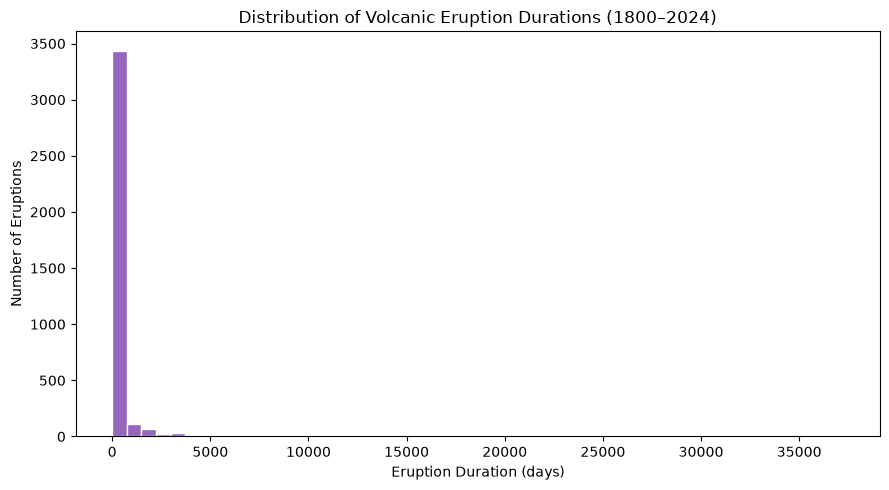

Chart Saved.


In [ ]:
plt.figure(figsize=(9, 5))
plt.hist(
    eruptions['duration_days'],
    bins=50,
    color='C4',
    edgecolor='white'
)
plt.xlabel("Eruption Duration (days)")
plt.ylabel("Number of Eruptions")
plt.title("Distribution of Volcanic Eruption Durations (1800-2024)")
plt.tight_layout()

plt.savefig('./images/plots/eruption_duration_distribution.png', dpi=150, bbox_inches="tight")
plt.show()

print("Chart Saved.")


## 9. Visualization: Longest Completed Eruptions

A horizontal bar chart of the top completed eruptions, converted to years
for readability.

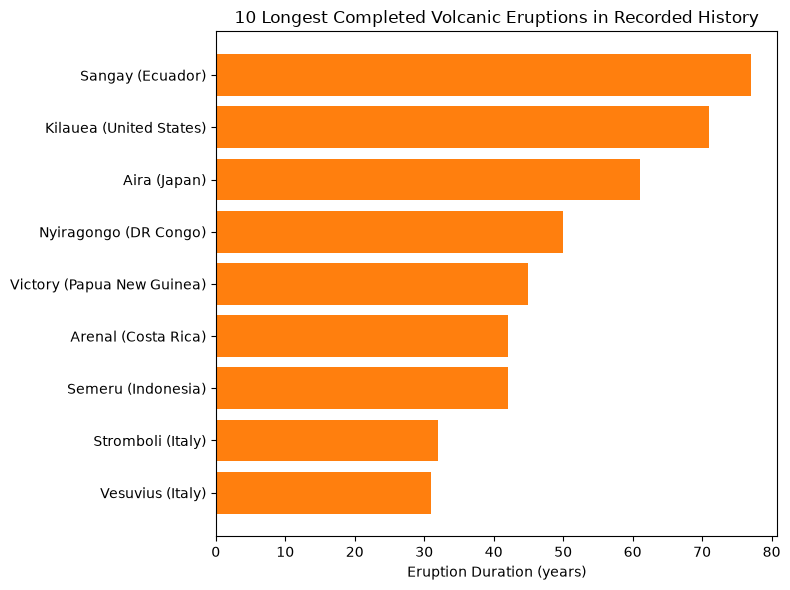

In [53]:
# Select the 10 completed eruptions with the longest recorded durations
longest_completed_10 = (completed.sort_values('duration_days', ascending=False).head(10).copy())
longest_completed_10['duration_years'] = (longest_completed_10['duration_days'] / 365.25)
labels = (longest_completed_10['volcano_name'] + ' (' + longest_completed_10['country'] + ')')

plt.figure(figsize=(8, 6))

# Convert eruption duration from days to years for easier interpretation
plt.barh(
    labels, longest_completed_10['duration_years'], 
    color='C1'
)

plt.gca().invert_yaxis()   

plt.xlabel("Eruption Duration (years)")
plt.title("10 Longest Completed Volcanic Eruptions in Recorded History")
plt.tight_layout()

plt.show()

## 10. My Own Question: Which Volcanoes Have Erupted the MOST Times?

A different ranking from "longest eruption", this measures frequency
of activity, not duration.

In [45]:
eruption_count = merged.groupby('volcano_name').size().sort_values(ascending=False).head(10)
print("Volcanoes with the most recorded eruptions since 1800: \n")
print(eruption_count)

Volcanoes with the most recorded eruptions since 1800: 

volcano_name
Fournaise, Piton de la    127
Asosan                     76
Etna                       67
Klyuchevskoy               65
Asamayama                  54
Bezymianny                 49
Marapi                     49
Merapi                     46
Tengger Caldera            45
Mayon                      45
dtype: int64


## 11. Key Insights

- As of the dataset's extraction in **December 2024**, **41 volcanoes** were still experiencing ongoing eruptions, demonstrating that volcanic activity can persist for many years or even decades.

- The longest recorded eruption durations differ depending on whether ongoing eruptions are included. Since active eruptions have no confirmed end date, their reported durations represent **lower-bound estimates** rather than final durations.

- The longest completed eruptions lasted for several decades, with **Sangay (Ecuador)** and **Kīlauea (United States)** recording the greatest confirmed durations in the dataset.

- **Fournaise, Piton de la** has the highest number of recorded eruptions since 1800, showing that eruption frequency and eruption duration measure different aspects of volcanic activity.

- The distribution of eruption durations is **highly right-skewed**. Most eruptions lasted for relatively short periods, while only a few continued for decades, creating extreme outliers.

- Merging the eruption records with the volcano reference dataset successfully enriched each eruption with volcano information, and no unmatched records were found during the merge.